In [1]:
import pandas as pd
import numpy as np

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
X = train.drop("label", axis=1).values
Y = train["label"].values

In [9]:
# Normalize pixel values (0–255 → 0–1)
X = X / 255.0

In [10]:
# Reshape to images (needed for CNN)
X = X.reshape(-1, 28, 28, 1)

**Train Test Split**

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_value, Y_train, Y_value = train_test_split(X, Y, test_size = 0.1,
                                                      random_state = 42)

**Build CNN Model**

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [13]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Training**

In [15]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_value, Y_value),
    epochs=10,
    batch_size=64
)

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.6274 - loss: 1.1727 - val_accuracy: 0.8758 - val_loss: nan
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.8785 - loss: 0.4019 - val_accuracy: 0.9477 - val_loss: nan
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9219 - loss: 0.2637 - val_accuracy: 0.9630 - val_loss: nan
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.9362 - loss: 0.2066 - val_accuracy: 0.9608 - val_loss: nan
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9464 - loss: 0.1776 - val_accuracy: 0.9651 - val_loss: nan
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.9535 - loss: 0.1553 - val_accuracy: 0.9739 - val_loss: nan
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9634 - loss: 0.1241 - val_accuracy: 0.9717 - val_loss: nan
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9663 - loss: 0.1094 - val_accuracy: 0.9782 - val_loss: nan
Epoch 9/

**Evaluation**

In [49]:
val_loss, val_acc = model.evaluate(X_value, Y_value)
print("---------------------------------------")
print(f"Validation Accuracy: {val_acc}")
print("---------------------------------------")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9760 - loss: nan   
---------------------------------------
Validation Accuracy: 0.9760348796844482
---------------------------------------


**Confusion Matrix**

In [21]:
from sklearn.metrics import confusion_matrix

In [22]:
y_pred = np.argmax(model.predict(X_value), axis=-1)
cm = confusion_matrix(Y_value, y_pred)
print(cm)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
[[53  0  0  0  0  0  0  0  0  0]
 [ 0 51  0  0  0  0  0  0  0  0]
 [ 0  0 46  0  0  0  0  0  0  0]
 [ 0  0  2 36  0  0  0  0  0  0]
 [ 0  0  0  0 41  0  0  0  0  0]
 [ 1  0  0  1  0 43  2  0  0  1]
 [ 1  0  0  0  0  0 46  0  0  0]
 [ 0  0  1  0  0  0  0 47  0  1]
 [ 0  0  0  0  0  1  0  0 44  0]
 [ 0  0  0  0  0  0  0  0  0 41]]


**Visualization**

In [31]:
import matplotlib.pyplot as plt

In [35]:
# Predict on validation set
y_pred = np.argmax(model.predict(X_value), axis=1)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [36]:
# Display some images with predictions
plt.figure(figsize=(10,10))

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

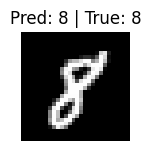

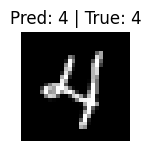

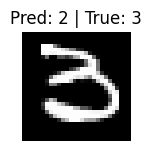

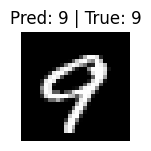

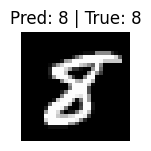

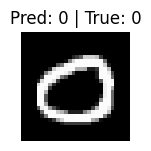

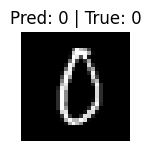

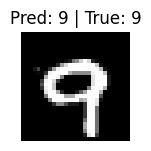

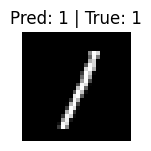

In [50]:
for i in range(9):  # show 9 images
    plt.subplot(3,3,i+1)
    plt.imshow(X_value[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {y_pred[i]} | True: {Y_value[i]}")
    plt.axis('off')

    plt.show()

**Wrong Predictions**

In [41]:
# Find wrong predictions
wrong = np.where(y_pred != Y_value)[0]

In [43]:
plt.figure(figsize=(10,10))

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

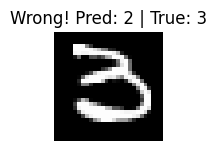

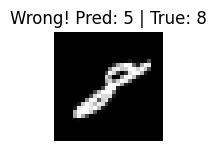

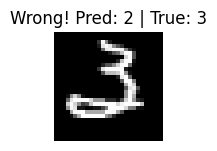

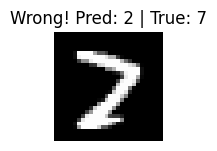

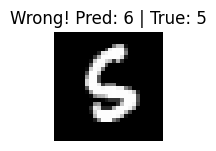

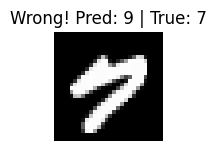

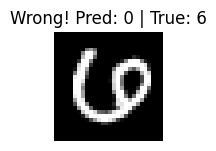

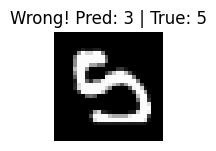

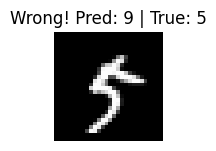

In [45]:
for i in range(9):
    idx = wrong[i]
    plt.subplot(3,3,i+1)
    plt.imshow(X_value[idx].reshape(28,28), cmap='gray')
    plt.title(f"Wrong! Pred: {y_pred[idx]} | True: {Y_value[idx]}")
    plt.axis('off')

    plt.show()

**Data Augmentation**

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [25]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

In [26]:
datagen.fit(X_train)

**Early Stop**

In [27]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [28]:
early_stop

**Model Saving**

In [30]:
model.save("mnist_model.keras")